In [36]:
import time
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile
import os
import shutil
from skimage.util.shape import view_as_windows
import yaml
import argparse

In [41]:
model = YOLO(r'C:\Users\lmcke\PycharmProjects\yolo_fires\best.pt')
result = model.predict(r"C:\Users\lmcke\Documents\JPL\input_tiles\images\test\MASTERL1B_1981725_01_20190817_0004_0007_V01.fire_7_4.tif", imgsz=160, save=False, save_txt=True, save_conf=True, conf=0.01, retina_masks=True, batch=1)



image 1/1 C:\Users\lmcke\Documents\JPL\input_tiles\images\test\MASTERL1B_1981725_01_20190817_0004_0007_V01.fire_7_4.tif: 160x160 87 items, 132.8ms
Speed: 1.3ms preprocess, 132.8ms inference, 25.5ms postprocess per image at shape (1, 3, 160, 160)
Results saved to runs\segment\predict4
1 label saved to runs\segment\predict4\labels


In [42]:
result

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'item'}
 obb: None
 orig_img: array([[[4, 3, 2],
         [4, 3, 2],
         [4, 3, 2],
         ...,
         [4, 3, 2],
         [4, 3, 2],
         [4, 3, 2]],
 
        [[4, 3, 2],
         [4, 3, 2],
         [4, 3, 2],
         ...,
         [4, 3, 2],
         [4, 3, 3],
         [4, 3, 2]],
 
        [[4, 3, 2],
         [4, 3, 2],
         [4, 3, 2],
         ...,
         [4, 3, 3],
         [4, 3, 2],
         [4, 3, 2]],
 
        ...,
 
        [[4, 3, 2],
         [4, 3, 2],
         [4, 3, 2],
         ...,
         [5, 4, 3],
         [5, 4, 3],
         [5, 4, 3]],
 
        [[4, 3, 2],
         [4, 3, 2],
         [4, 3, 2],
         ...,
         [5, 4, 3],
         [5, 5, 4],
         [5, 4, 3]],
 
        [[4, 3, 2],
         [4, 3, 2],
         [4, 3, 2],
         ...,
         [

In [43]:
masks = result[0].masks

In [44]:
np.shape(masks)

torch.Size([87, 160, 160])

In [45]:
masks = result[0].masks.data.cpu().numpy()        # (N, H, W), float32 in [0,1]
binary_masks = (masks > 0.01).astype(np.uint8)
combined_mask = np.any(binary_masks, axis=0).astype(np.uint8)


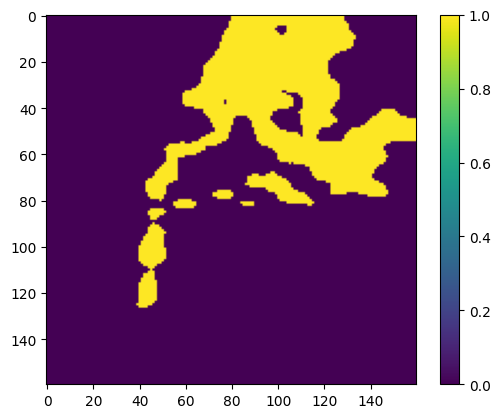

In [46]:
plt.figure()
plt.imshow(combined_mask)
plt.colorbar()
plt.show()

In [47]:
gt_mask = np.squeeze(cv2.imread(r"C:\Users\lmcke\Documents\JPL\input_tiles\pngTiles\test\MASTERL1B_1981725_01_20190817_0004_0007_V01.fire_7_4.png", cv2.IMREAD_GRAYSCALE)).astype(float)
tile = 2*combined_mask
res_mask = tile + gt_mask
res_mask[res_mask==0] = np.nan

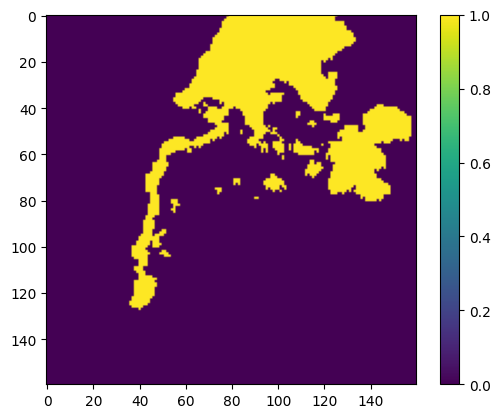

In [48]:
plt.figure()
plt.imshow(gt_mask)
plt.colorbar()
plt.show()

(np.float64(-0.5), np.float64(159.5), np.float64(159.5), np.float64(-0.5))

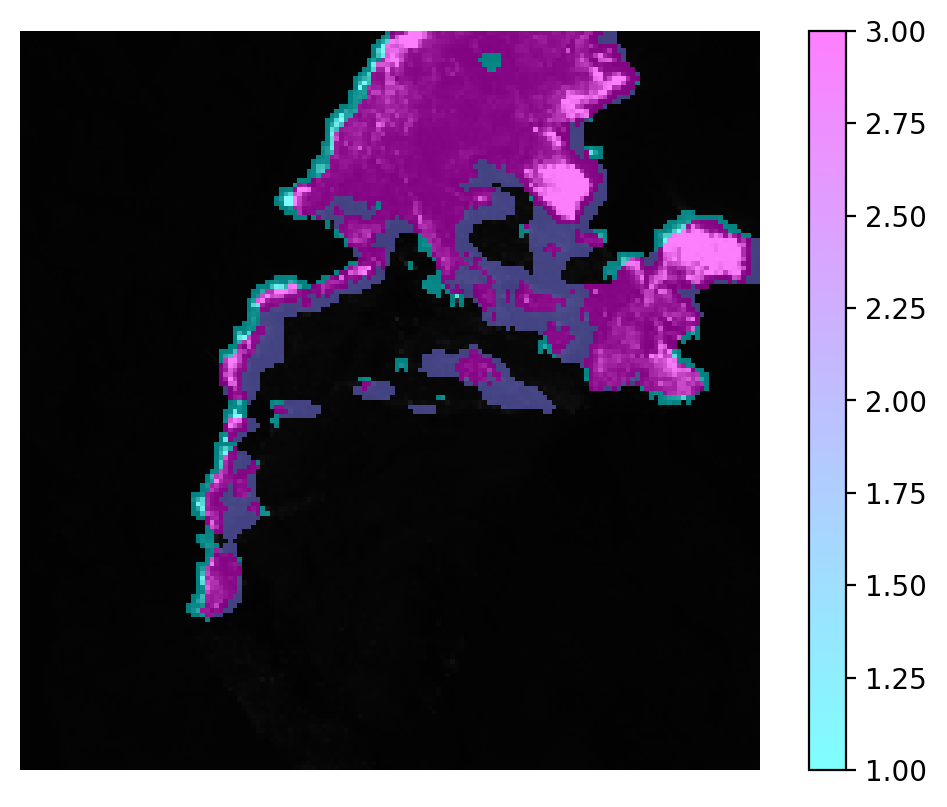

In [49]:
image = tifffile.imread(r"C:\Users\lmcke\Documents\JPL\input_tiles\images\test\MASTERL1B_1981725_01_20190817_0004_0007_V01.fire_7_4.tif")

plt.figure(dpi=200)
plt.imshow(image[:,:,0], vmin=0, vmax=255, cmap='gray')
plt.imshow(res_mask, cmap='cool', alpha=0.5)
plt.colorbar()
plt.axis('off')